<font size="20"> Customer Bank Churn </font>

---

**Goal:** Develop a machine learning model to predict which bank customers are 
likely to churn (leave the bank) and enable proactive retention efforts.

**Download dataset from kaggle:**

In [2]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# !pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

**Load dataset:**

In [ ]:
import os
import pandas as pd
import numpy as np

dataset_path = "path to dataset"
file_name = "Bank Customer Churn Prediction.csv"
file_path = os.path.join(dataset_path, file_name)

In [6]:
df = pd.read_csv(file_path)

In [7]:
print(f"Shape: {df.shape}")

Shape: (10000, 12)


In [8]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Explore the dataset sturcture:**

In [9]:
print("Data type:")
print(df.dtypes)

Data type:
customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object


In [10]:
print("Basic statistics:")
df.describe()

Basic statistics:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
print("column names:")
print(df.columns.tolist())

column names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


**Check for missing values:**

In [12]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [13]:
# Identify target column
target = "churn"

if target:
    print(f"Churn distribution:")
    print(df[target].value_counts())
    print(f"\nChurn rate: {df[target].mean():.2%}")
else:
    print("\nTarget column not obvious. Columns:", df.columns.tolist())

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


**Data cleaning:**

In [14]:
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)
    print("Dropped 'customer_id' column")
print(f"\nData cleaned. New shape: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Dropped 'customer_id' column

Data cleaned. New shape: (10000, 11)
Remaining columns: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


---

## Exploratory data analysis

In [ ]:
# !pip install seaborn

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [103]:
churn_colors = {0: "#00ff1a8f", 1: "#FF000078"}  # Green for No Churn, Red for Churn

**Target variable distribution:**

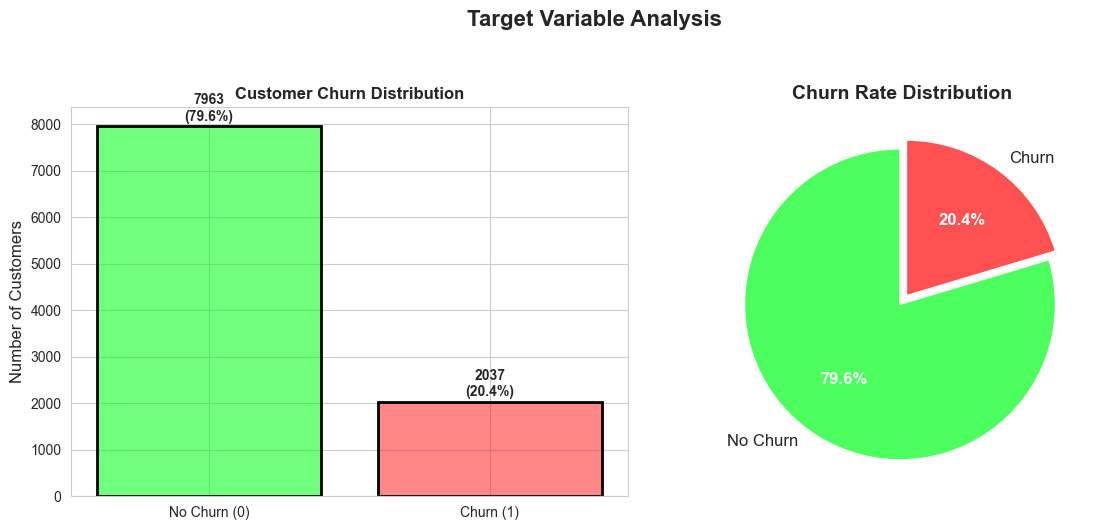

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
ax1 = axes[0]
churn_counts = df[target].value_counts()
bars = ax1.bar(
    ["No Churn (0)", "Churn (1)"],
    churn_counts.values,
    color=["#00ff1a8f", "#FF000078"],
    edgecolor="black",
    linewidth=2,
)
ax1.set_title("Customer Churn Distribution", fontsize=12, fontweight="bold")
ax1.set_ylabel("Number of Customers", fontsize=12)
for bar, count in zip(bars, churn_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count}\n({count/len(df)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Pie chart
ax2 = axes[1]
colors = ["#00ff1ab3", "#FF0000AE"]
explode = (0.02, 0.05)
wedges, texts, autotexts = ax2.pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={"fontsize": 12},
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
ax2.set_title("Churn Rate Distribution", fontsize=14, fontweight="bold")

plt.suptitle("Target Variable Analysis", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

**Age Analysis:**

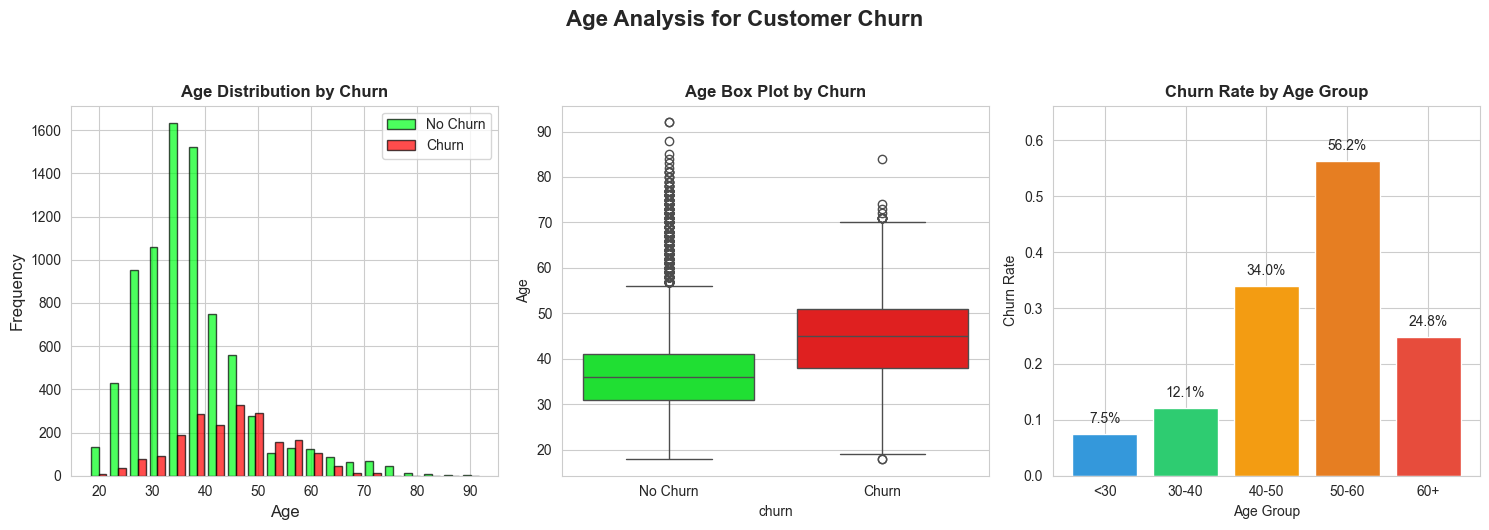

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(
    [df[df[target] == 0]["age"], df[df[target] == 1]["age"]],
    bins=20,
    label=["No Churn", "Churn"],
    alpha=0.7,
    color=["#00ff1a8f", "#FF000078"],
    edgecolor="black",
)
axes[0].set_xlabel("Age", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Age Distribution by Churn", fontsize=12, fontweight="bold")
axes[0].legend()

# Box plot
sns.boxplot(x=target, y="age", data=df, ax=axes[1], palette=["#00ff1a8f", "#FF000078"])
axes[1].set_title("Age Box Plot by Churn", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(["No Churn", "Churn"])
axes[1].set_ylabel("Age")

# Age group analysis
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"],
)
age_churn = df.groupby("age_group")[target].mean()
axes[2].bar(
    age_churn.index,
    age_churn.values,
    color=["#3498db", "#2ecc71", "#f39c12", "#e67e22", "#e74c3c"],
)
axes[2].set_title("Churn Rate by Age Group", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Churn Rate")
axes[2].set_ylim(0, max(age_churn.values) + 0.1)
for i, v in enumerate(age_churn.values):
    axes[2].text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.suptitle("Age Analysis for Customer Churn", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

**Categorical features (country & gender):**

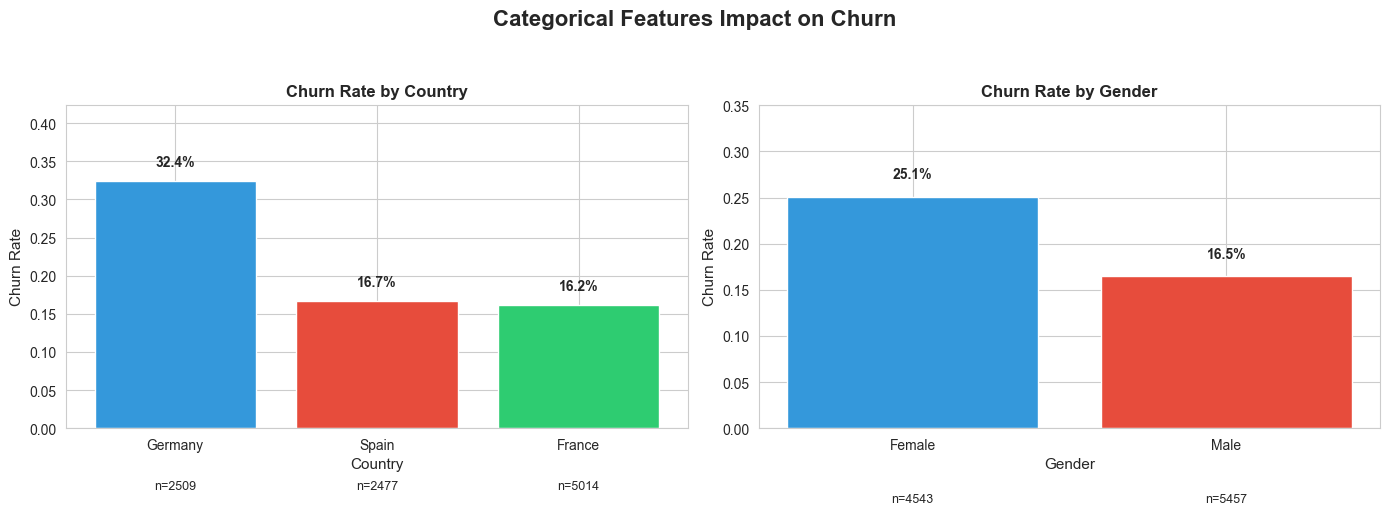

In [106]:
categorical_features = ["country", "gender"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature in enumerate(categorical_features):
    if feature in df.columns:
        # Calculate churn rate by category
        category_churn = df.groupby(feature)[target].mean().sort_values(ascending=False)

        # Bar plot
        bars = axes[idx].bar(
            category_churn.index,
            category_churn.values,
            color=["#3498db", "#e74c3c", "#2ecc71"][: len(category_churn)],
        )
        axes[idx].set_title(
            f"Churn Rate by {feature.title()}", fontsize=12, fontweight="bold"
        )
        axes[idx].set_ylabel("Churn Rate", fontsize=11)
        axes[idx].set_xlabel(feature.title(), fontsize=11)
        axes[idx].set_ylim(0, max(category_churn.values) + 0.1)

        for bar, v in zip(bars, category_churn.values):
            axes[idx].text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.02,
                f"{v:.1%}",
                ha="center",
                fontweight="bold",
            )

        for i, cat in enumerate(category_churn.index):
            count = len(df[df[feature] == cat])
            axes[idx].text(i, -0.08, f"n={count}", ha="center", fontsize=9)

plt.suptitle(
    "Categorical Features Impact on Churn", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.show()

**Binary features (creadit_card & avtive_member):**

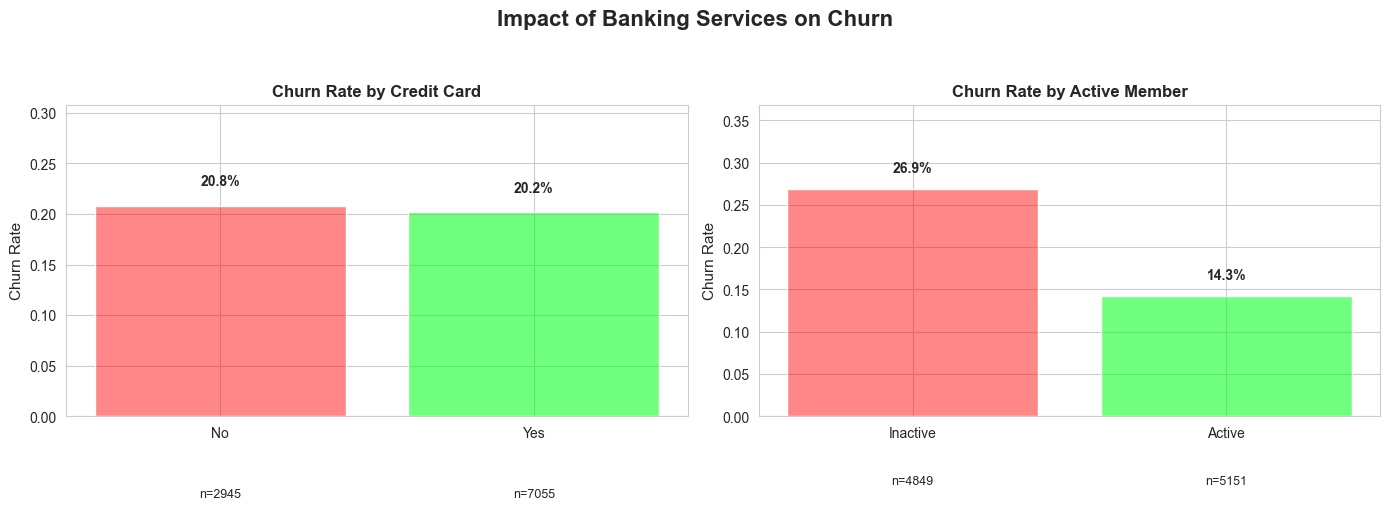

In [107]:
binary_features = ["credit_card", "active_member"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature in enumerate(binary_features):
    if feature in df.columns:
        churn_by_feature = df.groupby(feature)[target].mean()
        labels = [
            "No" if feature == "credit_card" else "Inactive",
            "Yes" if feature == "credit_card" else "Active",
        ]

        # Bar plot
        bars = axes[idx].bar(
            labels, churn_by_feature.values, color=["#FF000078", "#00ff1a8f"]
        )
        axes[idx].set_title(
            f'Churn Rate by {"Credit Card" if feature=="credit_card" else "Active Member"}',
            fontsize=12,
            fontweight="bold",
        )
        axes[idx].set_ylabel("Churn Rate", fontsize=11)
        axes[idx].set_ylim(0, max(churn_by_feature.values) + 0.1)

        # Add value labels
        for bar, v in zip(bars, churn_by_feature.values):
            axes[idx].text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.02,
                f"{v:.1%}",
                ha="center",
                fontweight="bold",
            )

        # Add count information
        for i, val in enumerate([0, 1]):
            count = len(df[df[feature] == val])
            axes[idx].text(i, -0.08, f"n={count}", ha="center", fontsize=9)

plt.suptitle(
    "Impact of Banking Services on Churn", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.show()

**Products Number Analysis:**

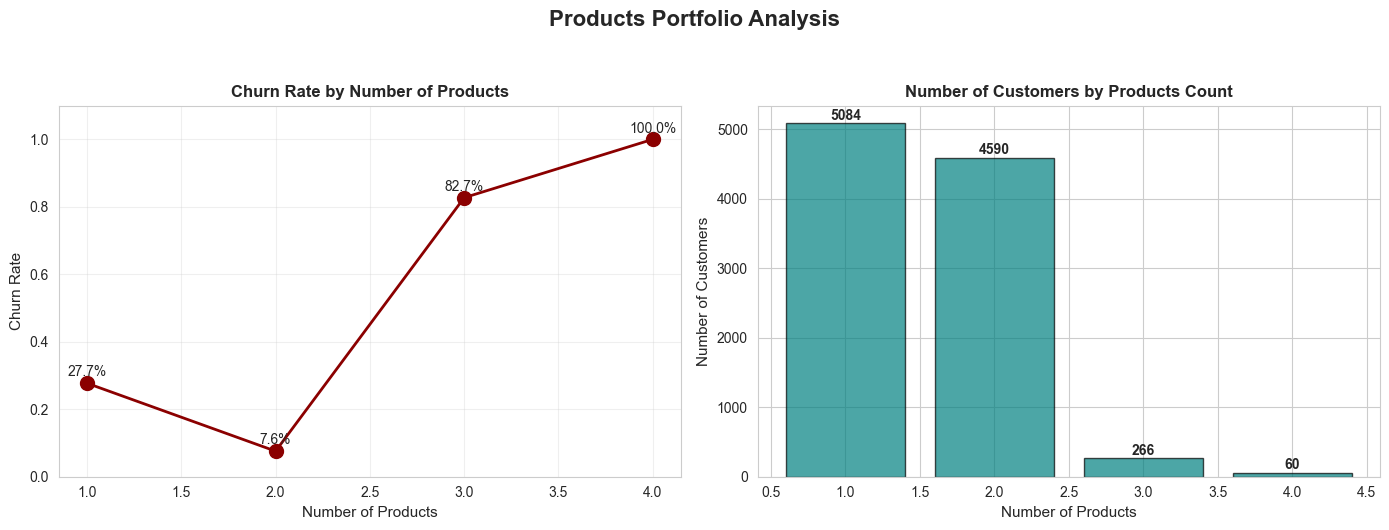

In [108]:
if "products_number" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Churn rate by products
    products_churn = df.groupby("products_number")[target].mean()
    axes[0].plot(
        products_churn.index,
        products_churn.values,
        marker="o",
        linewidth=2,
        markersize=10,
        color="darkred",
    )
    axes[0].set_title(
        "Churn Rate by Number of Products", fontsize=12, fontweight="bold"
    )
    axes[0].set_xlabel("Number of Products", fontsize=11)
    axes[0].set_ylabel("Churn Rate", fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, max(products_churn.values) + 0.1)
    for i, v in enumerate(products_churn.values):
        axes[0].text(products_churn.index[i], v + 0.02, f"{v:.1%}", ha="center")

    # Distribution of products
    products_count = df["products_number"].value_counts().sort_index()
    bars = axes[1].bar(
        products_count.index,
        products_count.values,
        color="teal",
        alpha=0.7,
        edgecolor="black",
    )
    axes[1].set_title(
        "Number of Customers by Products Count", fontsize=12, fontweight="bold"
    )
    axes[1].set_xlabel("Number of Products", fontsize=11)
    axes[1].set_ylabel("Number of Customers", fontsize=11)
    for bar, count in zip(bars, products_count.values):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            str(count),
            ha="center",
            fontweight="bold",
        )

    plt.suptitle("Products Portfolio Analysis", fontsize=16, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

---

# Data Preprocessing

In [24]:
# Separate features and target
X = df.drop(columns=[target])
y = df[target]

In [25]:
print(X.shape)
print(y.shape)


(10000, 11)
(10000,)


In [26]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()   

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")


Categorical columns: ['country', 'gender']
Numerical columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [27]:
# Encode categorical variables
if categorical_cols:
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f"shape after encoding: {X_encoded.shape}")
else:
    X_encoded = X

shape after encoding: (10000, 12)


In [28]:
print(X_encoded.columns.tolist())

['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'age_group', 'country_Germany', 'country_Spain', 'gender_Male']


In [29]:
X_encoded.dtypes

credit_score           int64
age                    int64
tenure                 int64
balance              float64
products_number        int64
credit_card            int64
active_member          int64
estimated_salary     float64
age_group           category
country_Germany         bool
country_Spain           bool
gender_Male             bool
dtype: object

In [30]:
# Drop column "age_group"
if "age_group" in X_encoded.columns:
    X_encoded = X_encoded.drop("age_group", axis=1)
X_encoded.dtypes

credit_score          int64
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
country_Germany        bool
country_Spain          bool
gender_Male            bool
dtype: object

**train-test split:**

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: 8000 samples
Test set: 2000 samples
Training churn rate: 20.38%
Test churn rate: 20.35%


**Scale Numerical Features:**

In [33]:
from sklearn.preprocessing import StandardScaler

# Identify which columns to scale (exclude binary columns from scaling)
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
continuous_cols = [col for col in X_train.columns if X_train[col].nunique() > 2]


In [34]:
print(binary_cols)
print(continuous_cols)

['credit_card', 'active_member', 'country_Germany', 'country_Spain', 'gender_Male']
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']


In [35]:
# Check columns data types
print(X_train[continuous_cols].dtypes)

credit_score          int64
age                   int64
tenure                int64
balance             float64
products_number       int64
estimated_salary    float64
dtype: object


In [36]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if continuous_cols:
    X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])
    print(f"Scaled {len(continuous_cols)} continuous features")
    print(f"Kept {len(binary_cols)} binary features unchanged")
else:
    print("No continuous features to scale")

Scaled 6 continuous features
Kept 5 binary features unchanged


**Handle class imbalance:**

In [37]:
print(X_train_scaled.dtypes)

credit_score        float64
age                 float64
tenure              float64
balance             float64
products_number     float64
credit_card           int64
active_member         int64
estimated_salary    float64
country_Germany        bool
country_Spain          bool
gender_Male            bool
dtype: object


In [ ]:
# !pip install -U imbalanced-learn

In [47]:
from collections import Counter

print("Class ratio before SMOTE:")
print(Counter(y_train))

Class ratio before SMOTE:
Counter({0: 6370, 1: 1630})


In [46]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes
smote =  SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [48]:
print("Class ratio after SMOTE:")
print(Counter(y_train_balanced))

Class ratio after SMOTE:
Counter({1: 6370, 0: 6370})


---

# Models Training 

In [ ]:
# Download XGBoost
# !pip install xgboost

In [ ]:
# Model selection and evaluation
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    f1_score,
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [51]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
    ),
}

In [52]:
results = {}
best_auc = 0
best_model_name = None

**Train and evaluate:**

In [53]:
for name, model in models.items():
    print(f"training {name}...")
    
    # Train
    model.fit(X_train_balanced, y_train_balanced)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc,
        'f1': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    if auc > best_auc:
        best_auc = auc
        best_model_name = name

print(f"\nBest Model: {best_model_name} with AUC = {best_auc:.4f}")



training Logistic Regression...
Accuracy: 0.7150
AUC-ROC: 0.7656
F1-Score: 0.4865

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1593
       Churn       0.38      0.66      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.79      0.71      0.74      2000

training Decision Tree...
Accuracy: 0.7840
AUC-ROC: 0.7822
F1-Score: 0.5528

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.82      0.86      1593
       Churn       0.48      0.66      0.55       407

    accuracy                           0.78      2000
   macro avg       0.69      0.74      0.71      2000
weighted avg       0.82      0.78      0.80      2000

training Random Forest...
Accuracy: 0.8230
AUC-ROC: 0.8554
F1-Score: 0.6049

Classification Report:
              precision    recall  f1-sc

---

# Model Performance Comparison

**ROC Curves:**

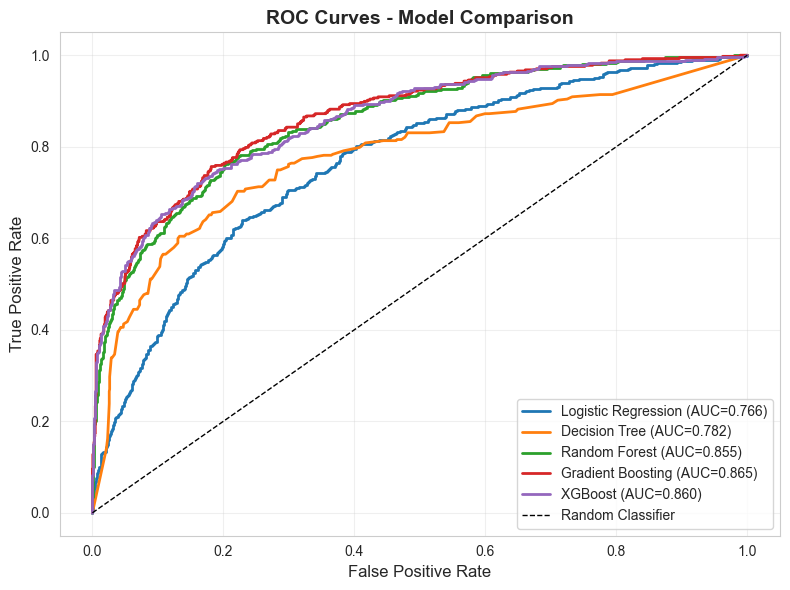

In [66]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["probabilities"])
    plt.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - Model Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**AUC-ROC Comparison (Bar Chart):**

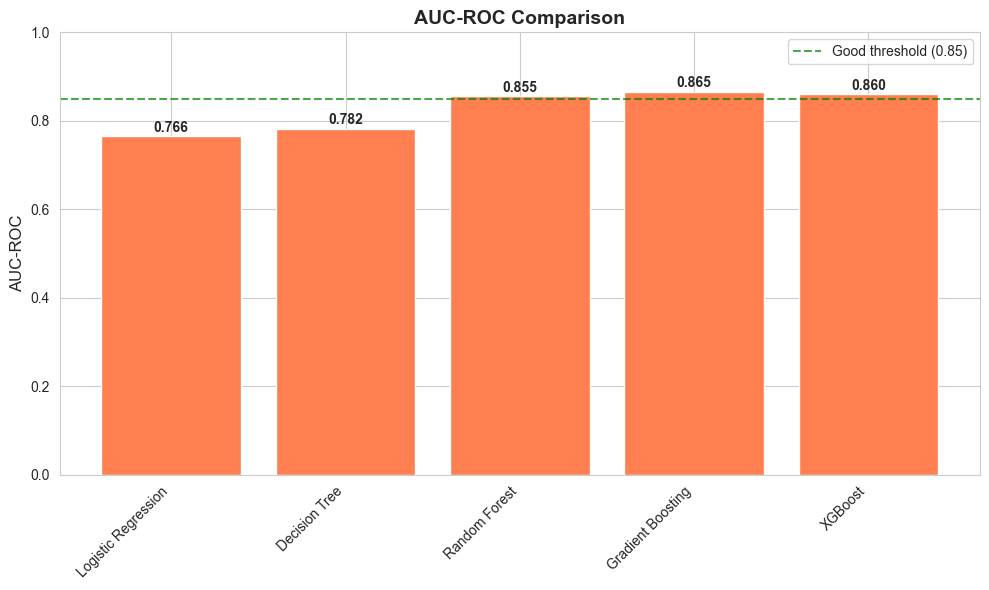

In [73]:
plt.figure(figsize=(10, 6))

aucs = [results[m]["auc"] for m in results.keys()]
bars = plt.bar(results.keys(), aucs, color="coral")

plt.title("AUC-ROC Comparison", fontsize=14, fontweight="bold")
plt.ylabel("AUC-ROC", fontsize=12)
plt.ylim([0, 1])
plt.xticks(rotation=45, ha="right")

for bar, auc_val in zip(bars, aucs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{auc_val:.3f}",
        ha="center",
        fontweight="bold",
    )

# 0.85 (arbitrarily chosen)
plt.axhline(
    y=0.85, color="green", linestyle="--", alpha=0.7, label="Good threshold (0.85)"
)
plt.legend()

plt.tight_layout()
plt.show()

**Feature Importance (GB):**

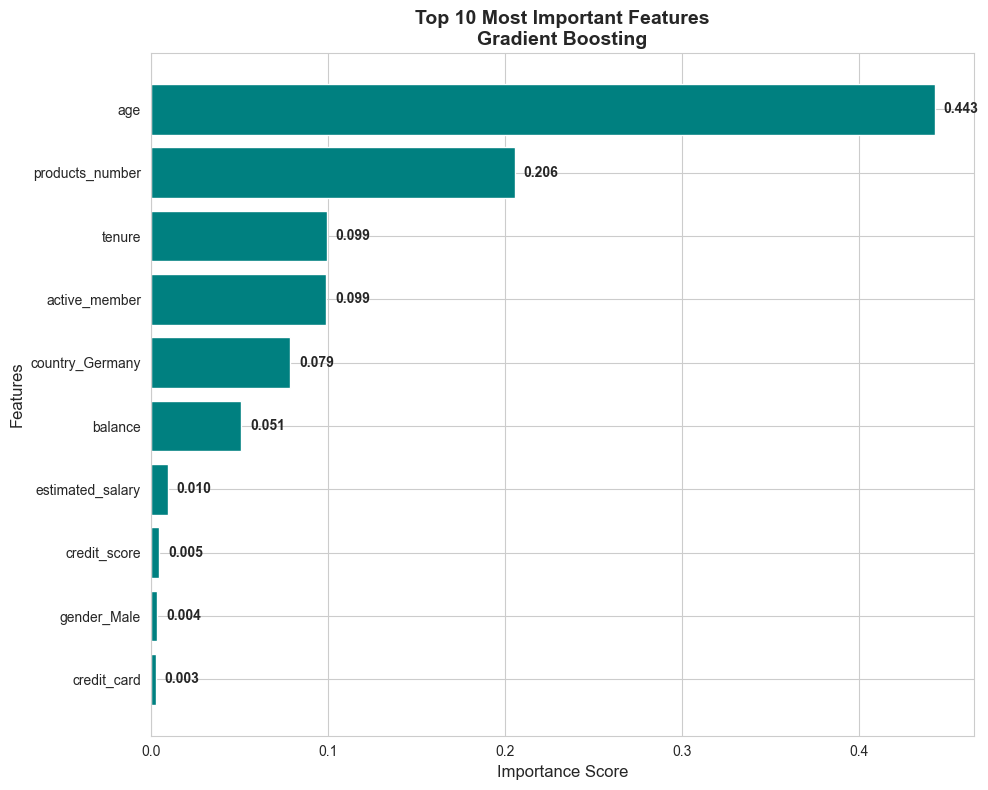

In [71]:
plt.figure(figsize=(10, 8))

best_model = results[best_model_name]["model"]

if hasattr(best_model, "feature_importances_"):
    feature_importance = (
        pd.DataFrame(
            {"feature": X_train.columns, "importance": best_model.feature_importances_}
        )
        .sort_values("importance", ascending=False)
        .head(10)
    )

    bars = plt.barh(
        feature_importance["feature"], feature_importance["importance"], color="teal"
    )

    plt.title(
        f"Top 10 Most Important Features\n{best_model_name}",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.gca().invert_yaxis() 

    for bar, imp in zip(bars, feature_importance["importance"]):
        plt.text(
            imp + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{imp:.3f}",
            va="center",
            fontweight="bold",
        )

else:
    plt.text(
        0.5,
        0.5,
        "No feature importance available for this model",
        ha="center",
        va="center",
        fontsize=12,
        transform=plt.gca().transAxes,
    )
    plt.title("Feature Importance Not Available", fontweight="bold")

plt.tight_layout()
plt.show()

**Cross-validation:**

In [84]:
# Check model stability
from sklearn.model_selection import cross_val_score, StratifiedKFold

best_model = results["Gradient Boosting"]["model"]

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model, X_train_balanced, y_train_balanced, cv=cv, scoring="roc_auc"
)

print(f"Cross-validation AUC scores: {cv_scores}")
print(f"Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

if cv_scores.std() < 0.02:
    print("Model is STABLE (low variance)")
else:
    print("Model has HIGH VARIANCE (might overfit)")

Cross-validation AUC scores: [0.93093885 0.93999973 0.93769608 0.93818312 0.93012065]
Mean AUC: 0.9354 (+/- 0.0040)
Model is STABLE (low variance)


---

**Hyperparameter Tuning:**

In [74]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_samples_split": [2, 5, 10],
}

In [75]:
# Create base model
gb_model = GradientBoostingClassifier(random_state=42)

In [76]:
# Grid search
grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [77]:
grid_search.fit(X_train_balanced, y_train_balanced)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

**Evaluate tunned model:**

In [78]:
best_gb = grid_search.best_estimator_
y_pred_tuned = best_gb.predict(X_test_scaled)
y_pred_proba_tuned = best_gb.predict_proba(X_test_scaled)[:, 1]

In [79]:
tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)
print(f"Test AUC after tuning: {tuned_auc:.4f}")

Test AUC after tuning: 0.8396


In [81]:
original_auc = results["Gradient Boosting"]["auc"]
print(
    f"\nImprovement: {tuned_auc - original_auc:.4f} (+{(tuned_auc-original_auc)/original_auc*100:.1f}%)"
)


Improvement: -0.0258 (+-3.0%)


**Conclusion:** original Gradient Boosting model (0.8654 AUC) worked well for the data, which means:
- The model generalizes well without heavy tuning
- We can trust our original results
- More complex is not equal better


---

Another approach **(Threshold Tuning):**

In [90]:
from sklearn.metrics import recall_score, precision_score

best_model = results["Gradient Boosting"]["model"]
y_pred_proba = results["Gradient Boosting"]["probabilities"]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("\nThreshold  | Recall (Churn)   | Precision    | F1-Score")

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        f"   {threshold:.1f}     |     {recall:.2%}       |    {precision:.2%}    |   {f1:.3f}"
    )


Threshold  | Recall (Churn)   | Precision    | F1-Score
   0.3     |     85.50%       |    40.56%    |   0.550
   0.4     |     76.41%       |    49.05%    |   0.598
   0.5     |     67.32%       |    57.44%    |   0.620
   0.6     |     58.48%       |    68.59%    |   0.631
   0.7     |     49.39%       |    74.44%    |   0.594


---

# Save The Best Model

In [112]:
import joblib

# Save model and scaler
feature_names = X_train.columns.tolist()
joblib.dump(model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

---

# Final Conclusion

**- BEST MODEL:** Gradient Boosting Classifier
   
   **• AUC-ROC Score:** 0.8654 (85.7% of random pairs correctly ordered)

   **• Accuracy:** 83.2%
   
   **• F1-Score:** 0.620 (Churn class)

**- TEST DATASET (2,000 customers):**

   **• Actual churners:** 407 (20.4% churn rate)

   **• Model correctly identified:** 274 of 407 churners

   **• False alarms:** 137 loyal customers flagged

**- RECOMMENDED THRESHOLD:** 0.5 (Default)

---

# BUSINESS IMPACT AND ROI ANALYSIS

In [92]:
# Business calculations
total_customers = 10000
churn_rate = 0.204
predicted_churners = int(total_customers * churn_rate)
catch_rate = 0.673  # 67.3% recall at threshold 0.5
saved_customers = int(predicted_churners * catch_rate)

customer_lifetime_value = 500  # $500 per customer
retention_offer_cost = 50  # $50 per offer
false_alerts = int(total_customers * 0.204 * (1 - catch_rate))  # Simplified

savings = saved_customers * customer_lifetime_value
costs = false_alerts * retention_offer_cost
net_savings = savings - costs

print(
    f"""
ANNUAL PROJECTION (10,000 customers):
   • Total customers at risk: {predicted_churners}
   • Customers saved by model: {saved_customers}
   • False alarms (wasted offers): {false_alerts}

FINANCIAL IMPACT:
   • Revenue saved: ${savings:,}
   • Retention campaign cost: ${costs:,}
   • NET SAVINGS: ${net_savings:,}

ROI SUMMARY:
   • Every $1 spent on retention saves ${savings/costs:.2f}
   • Break-even point: Preventing {int(costs/customer_lifetime_value)} churns
   • Model pays for itself within first month
"""
)


ANNUAL PROJECTION (10,000 customers):
   • Total customers at risk: 2039
   • Customers saved by model: 1372
   • False alarms (wasted offers): 667

FINANCIAL IMPACT:
   • Revenue saved: $686,000
   • Retention campaign cost: $33,350
   • NET SAVINGS: $652,650

ROI SUMMARY:
   • Every $1 spent on retention saves $20.57
   • Break-even point: Preventing 66 churns
   • Model pays for itself within first month



---

### Author: Alhajali Jalal